In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib import pyplot as plt
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader, random_split
import torch
import sys
from functools import partial
import time
sys.path.append("..")
from src.models import NeuralPosteriorEstimator
from src.data.reinfection import AoN, Win
mps_device = torch.device("mps")

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
N = 200 # 2000
# noise = {"distr": "normal", "scale":1}
a = int(N * 0.8)
b = N - a

# III. AoN
All-or-nothing

In [3]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
alpha_prior = torch.distributions.Uniform(low=0.1, high=0.9)

In [4]:
aon_dataset = AoN(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    alpha=alpha_prior, notebook=True)
start = time.time()
aon_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
train_data, val_data = random_split(aon_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=2000)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...
Time to simulate 200 samples: 48.5s.


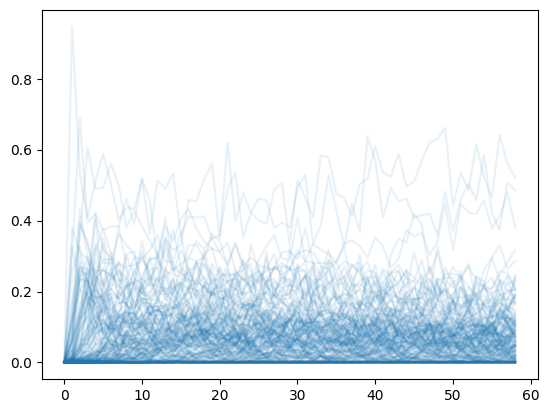

In [5]:
plt.plot(aon_dataset.data.T, alpha=0.1, color="tab:blue")
plt.show()

# VI. Win
Window-of-reinfection

In [3]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)
gamma_prior = torch.distributions.Exponential(rate=10)
tau_prior = torch.distributions.Exponential(rate=4)

In [4]:
win_dataset = Win(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, gamma=gamma_prior,
                                    tau=tau_prior, notebook=True)
start = time.time()
win_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
train_data, val_data = random_split(win_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=2000)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...
Time to simulate 200 samples: 15.7s.


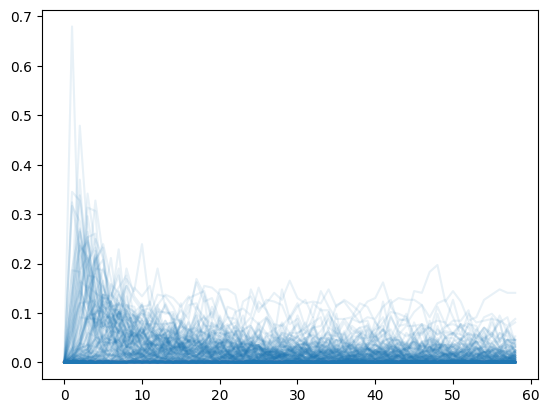

In [10]:
plt.plot(win_dataset.data.T, alpha=0.1, color="tab:blue")
plt.show()

In [25]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = NeuralPosteriorEstimator(4, 59, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 43.9 K | train
-------------------------------------------
43.9 K    Trainable params
0         Non-trainable params
43.9 K    Total params
0.176     Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                  | 0/? [00:00<?, ?it/s]

Training: |                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

...

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

In [26]:
x_o = base_dataset.get_observed_data()
posterior_sample = model.sample(100, x_o)
posterior_sample = base_dataset.transform_prior(posterior_sample, True)

In [27]:
prior_sample = base_dataset.transform_prior(base_dataset.theta, True)[:100]

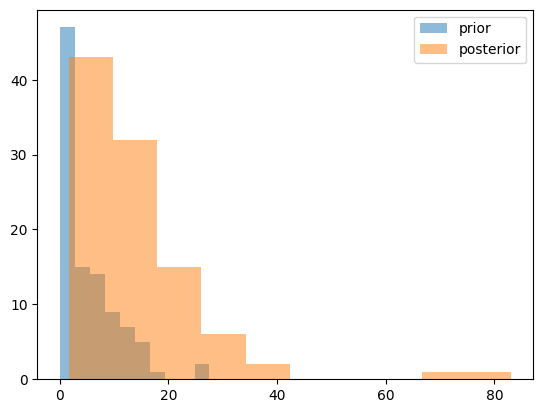

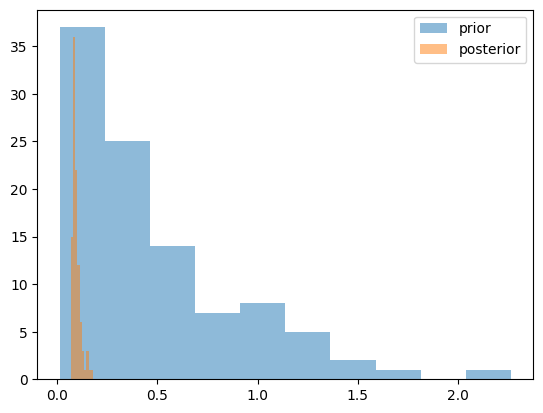

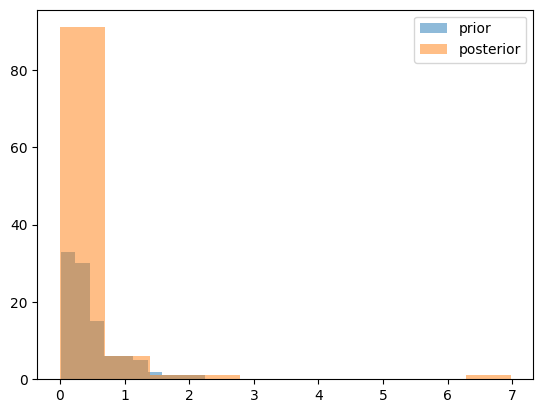

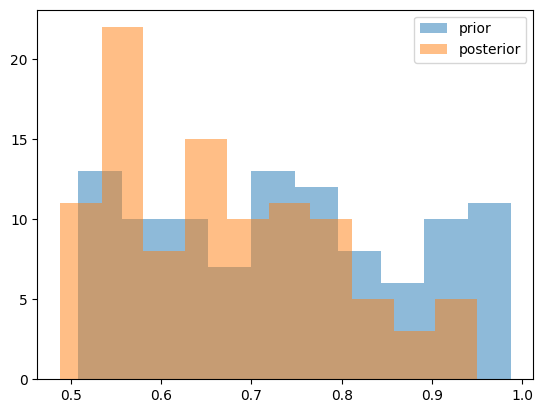

In [28]:
for i in range(4):
    plt.hist(prior_sample.T[i], alpha=0.5, label="prior")
    plt.hist(posterior_sample.T[i], alpha=0.5, label="posterior")
    plt.legend()
    plt.show()

In [30]:
parameters = ("beta", "epsilon", "nu", "rho")
for i, p in enumerate(parameters):
    print(f"Estimate of {p}: {posterior_sample.T[i].mean():.2f}")

Estimate of beta: 13.89
Estimate of epsilon: 0.10
Estimate of nu: 0.34
Estimate of rho: 0.67


# Predictive Checks

## Prior Predictive Checks

In [33]:
J = 100
prior_predictive = np.empty((J, 59))
for j in range(100):
    z = base_dataset.sample_prior(1, j)[0]
    x = base_dataset.simulate(z)
    prior_predictive[j] = x

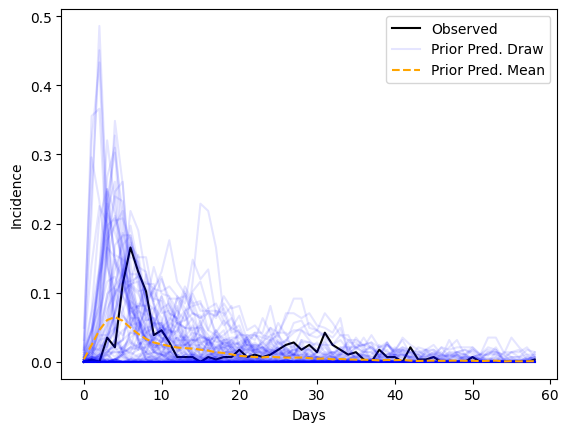

In [43]:
pp_mean = prior_predictive.mean(0)
labels = ["Prior Pred. Draw"] + [None for _ in range(J-1)]
plt.plot(x_o, label="Observed", color="k")
plt.plot(prior_predictive.T, label=labels, color="b", alpha=0.1)
plt.plot(pp_mean, label="Prior Pred. Mean", linestyle="--", color="orange")
plt.xlabel("Days")
plt.ylabel("Incidence")
plt.legend()
plt.show()

## Posterior Predictive Checks

In [42]:
J = 100
posterior_predictive = np.empty((J, 59))
for j in range(100):
    z = posterior_sample[j]
    x = base_dataset.simulate(z)
    posterior_predictive[j] = x

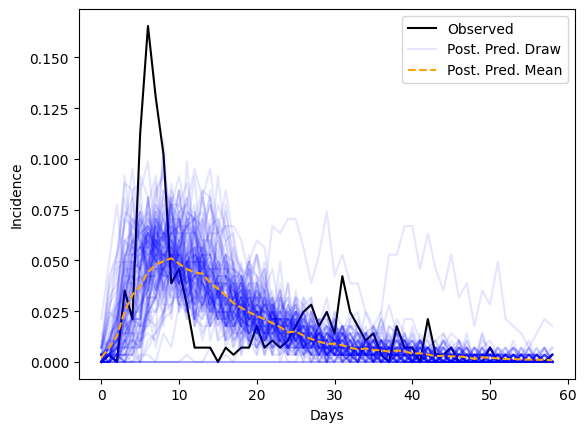

In [44]:
pp_mean = posterior_predictive.mean(0)
labels = ["Post. Pred. Draw"] + [None for _ in range(J-1)]
plt.plot(x_o, label="Observed", color="k")
plt.plot(posterior_predictive.T, label=labels, color="b", alpha=0.1)
plt.plot(pp_mean, label="Post. Pred. Mean", linestyle="--", color="orange")
plt.xlabel("Days")
plt.ylabel("Incidence")
plt.legend()
plt.show()

# Transformer Embeddings

In [12]:
optim = partial(torch.optim.AdamW, lr=0.001)
embedding = partial(TransformerEmbedding, d_model=8)
model = NeuralPosteriorEstimator(4, torch.Size([1, 59]), 5, flow_type="MAF", optimizer=optim, embedding=embedding)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type                 | Params | Mode 
-------------------------------------------------------
0 | embed | TransformerEmbedding | 904    | train
1 | flow  | MAF                  | 27.6 K | train
-------------------------------------------------------
28.5 K    Trainable params
0         Non-trainable params
28.5 K    Total params
0.114     Total estimated model params size (MB)
56        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                  | 0/? [00:00<?, ?it/s]

Training: |                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

...

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

In [13]:
x_o = base_dataset.get_observed_data()
posterior_sample = model.sample(100, x_o)
posterior_sample = base_dataset.transform_prior(posterior_sample, True)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (100x63 and 12x64)